In [1]:
students = ["A", "B", "C", "D"]
study_hours      = [1,  3,  5,  2]   # 공부 시간
attendance_rate  = [0.4, 0.7, 0.9, 0.5]   # 출석률
score_true       = [28, 52, 74, 39]   # 실제 시험 점수
pass_true        = [0,  1,  1,  0]    # 합격(1) / 불합격(0)

print("=== 공통 데이터셋 ===")
for i, name in enumerate(students):
    print(f"  학생 {name}: study={study_hours[i]}h, "
          f"attendance={attendance_rate[i]}, "
          f"score={score_true[i]}, pass={pass_true[i]}")

=== 공통 데이터셋 ===
  학생 A: study=1h, attendance=0.4, score=28, pass=0
  학생 B: study=3h, attendance=0.7, score=52, pass=1
  학생 C: study=5h, attendance=0.9, score=74, pass=1
  학생 D: study=2h, attendance=0.5, score=39, pass=0


In [3]:
# 이론 1 파트에서 설정한 가중치와 절편
w = 12   # 가중치: 공부 1시간당 점수 상승량
b = 16   # 절편: 기본 점수

def linear_predict(x, w, b):
    """
    선형회귀 예측 함수
    y_hat = w * x + b
    """
    #### [ 빈칸: 이 부분을 완성하세요 — y = wx + b ]
    return w * x + b

print("=== Step 2: 선형회귀 예측 (단일 특성: study_hours) ===")
predictions = []
for i, name in enumerate(students):
    y_hat = linear_predict(study_hours[i], w, b)
    predictions.append(y_hat)
    print(f"  학생 {name}: ŷ = 12×{study_hours[i]} + 16 = {y_hat:>5}  (실제: {score_true[i]})")

# 손계산 검증: A=28, B=52, C=76, D=40 이 나와야 합니다

=== Step 2: 선형회귀 예측 (단일 특성: study_hours) ===
  학생 A: ŷ = 12×1 + 16 =    28  (실제: 28)
  학생 B: ŷ = 12×3 + 16 =    52  (실제: 52)
  학생 C: ŷ = 12×5 + 16 =    76  (실제: 74)
  학생 D: ŷ = 12×2 + 16 =    40  (실제: 39)


In [4]:
import numpy as np
def calc_mse(y_true_list, y_pred_list):
    """
    평균 제곱 오차(MSE) 계산
    MSE = (1/m) * Σ(y - ŷ)²
    """
    m = len(y_true_list)
    y_true_list = np.array(y_true_list)
    y_pred_list = np.array(y_pred_list)
    return sum((y_true_list - y_pred_list)**2) / m    

print("\n=== Step 3: MSE 계산 ===")
for i, name in enumerate(students):
    err = score_true[i] - predictions[i]
    print(f"  학생 {name}: 오차={err:>3}, 제곱오차={err**2}")

mse = calc_mse(score_true, predictions)
print(f"\n  MSE = {mse}  ← 이론 2 손계산 결과와 동일해야 합니다 (기댓값: 1.25)")


=== Step 3: MSE 계산 ===
  학생 A: 오차=  0, 제곱오차=0
  학생 B: 오차=  0, 제곱오차=0
  학생 C: 오차= -2, 제곱오차=4
  학생 D: 오차= -1, 제곱오차=1

  MSE = 1.25  ← 이론 2 손계산 결과와 동일해야 합니다 (기댓값: 1.25)


In [15]:
import math

def sigmoid(z):
    """
    시그모이드 함수: 임의의 실수 z를 0~1 사이로 변환
    σ(z) = 1 / (1 + e^(-z))
    """
    #### [ 빈칸: 이 부분을 완성하세요 — 시그모이드 수식 ]
    return 1 / (1 + math.exp(-z))

def logistic_score(study, attendance, w_study, w_att, bias):
    """
    로지스틱 회귀의 raw score 계산
    z = w_study * study + w_att * attendance + bias
    """
    #### [ 빈칸: 이 부분을 완성하세요 — z = wx + b ]
    return w_study * study + w_att * attendance + bias

# 이론 4에서 설정한 가중치
w_study = 2.0
w_att   = 1.5
bias    = -5.0

print("\n=== Step 4: 로지스틱 회귀 분류 ===")
print(f"  설정: w_study={w_study}, w_attendance={w_att}, bias={bias}")
print(f"  {'학생':^4} | {'z(raw score)':>12} | {'σ(z)':>8} | {'예측':^10} | {'실제':^6} | {'일치':^4}")
print("  " + "-" * 60)

all_correct = True
for i, name in enumerate(students):
    z = logistic_score(study_hours[i], attendance_rate[i], w_study, w_att, bias)
    prob = sigmoid(z)
    predicted = 1 if prob >= 0.5 else 0
    correct = "✓" if predicted == pass_true[i] else "✗"
    if predicted != pass_true[i]:
        all_correct = False
    label_pred = "합격(1)" if predicted == 1 else "불합격(0)"
    label_true = "합격(1)" if pass_true[i] == 1 else "불합격(0)"
    print(f"  학생 {name}  | {z:>12.4f} | {prob:>8.3f} | {label_pred:^10} | {label_true:^8} | {correct:^4}")

print(f"\n  결론: {'4명 전원 올바르게 분류됨 ✓' if all_correct else '일치하지 않는 샘플 있음 ✗'}")


=== Step 4: 로지스틱 회귀 분류 ===
  설정: w_study=2.0, w_attendance=1.5, bias=-5.0
   학생  | z(raw score) |     σ(z) |     예측     |   실제   |  일치 
  ------------------------------------------------------------
  학생 A  |      -2.4000 |    0.083 |   불합격(0)   |  불합격(0)  |  ✓  
  학생 B  |       2.0500 |    0.886 |   합격(1)    |  합격(1)   |  ✓  
  학생 C  |       6.3500 |    0.998 |   합격(1)    |  합격(1)   |  ✓  
  학생 D  |      -0.2500 |    0.438 |   불합격(0)   |  불합격(0)  |  ✓  

  결론: 4명 전원 올바르게 분류됨 ✓


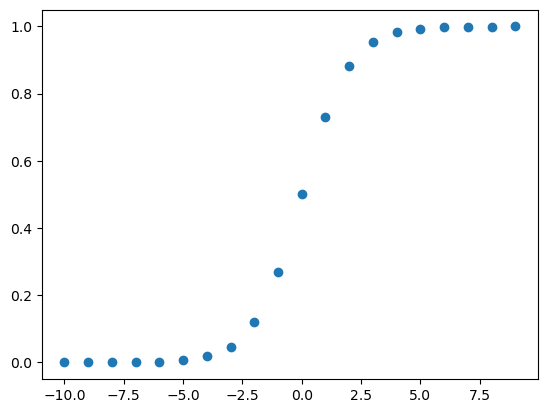

In [14]:
import math
def sigmoid(z):
    """
    시그모이드 함수: 임의의 실수 z를 0~1 사이로 변환
    σ(z) = 1 / (1 + e^(-z))
    """
    #### [ 빈칸: 이 부분을 완성하세요 — 시그모이드 수식 ]
    return 1 / (1 + math.exp(-z))
np.array(range(-10,10)), [sigmoid(data) for data in np.array(range(-10,10))]
import matplotlib.pylab as plt
plt.scatter(np.array(range(-10,10)), [sigmoid(data) for data in np.array(range(-10,10))])